In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.04G/3.06G [00:26<00:00, 234MB/s]
100% 3.06G/3.06G [00:26<00:00, 125MB/s]


In [3]:
!unzip galaxy-zoo-2-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: images_gz2/images/95074.jpg  
  inflating: images_gz2/images/95075.jpg  
  inflating: images_gz2/images/95076.jpg  
  inflating: images_gz2/images/95077.jpg  
  inflating: images_gz2/images/95078.jpg  
  inflating: images_gz2/images/95079.jpg  
  inflating: images_gz2/images/9508.jpg  
  inflating: images_gz2/images/95080.jpg  
  inflating: images_gz2/images/95081.jpg  
  inflating: images_gz2/images/95082.jpg  
  inflating: images_gz2/images/95083.jpg  
  inflating: images_gz2/images/95084.jpg  
  inflating: images_gz2/images/95085.jpg  
  inflating: images_gz2/images/95086.jpg  
  inflating: images_gz2/images/95087.jpg  
  inflating: images_gz2/images/95088.jpg  
  inflating: images_gz2/images/95089.jpg  
  inflating: images_gz2/images/9509.jpg  
  inflating: images_gz2/images/95090.jpg  
  inflating: images_gz2/images/95091.jpg  
  inflating: images_gz2/images/95092.jpg  
  inflating: images_gz2/images/95093.jpg  
  inf

In [4]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -f gz2_filename_mapping.csv

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/2.25M [00:00<?, ?B/s]
100% 2.25M/2.25M [00:00<00:00, 182MB/s]


In [5]:
# !unzip gz2_filename_mapping.csv.zip

#Collecting Galaxy Zoo 2 Morphology Table:

-As mentioned earlier, the most recent and reliable source for galaxy morphology is from Hart et al. (2016), available at data.galaxyzoo.org. Download the "GZ2 - Table 1 - Normal-depth sample with new debiasing method – CSV".

In [6]:
!wget https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

--2024-10-25 12:56:36--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 52.216.38.137, 16.182.42.17, 52.217.33.244, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|52.216.38.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘gz2_hart16.csv.gz’

gz2_hart16.csv.gz   100%[===================>]  74.88M  19.4MB/s    in 3.9s    

2024-10-25 12:56:40 (19.4 MB/s) - ‘gz2_hart16.csv.gz’ saved [78513011/78513011]



In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
# List files in the current directory
os.listdir()

['.config',
 'kaggle.json',
 'gz2_filename_mapping.csv.zip',
 'galaxy-zoo-2-images.zip',
 'gz2_filename_mapping.csv',
 'images_gz2',
 'gz2_hart16.csv.gz',
 'sample_data']

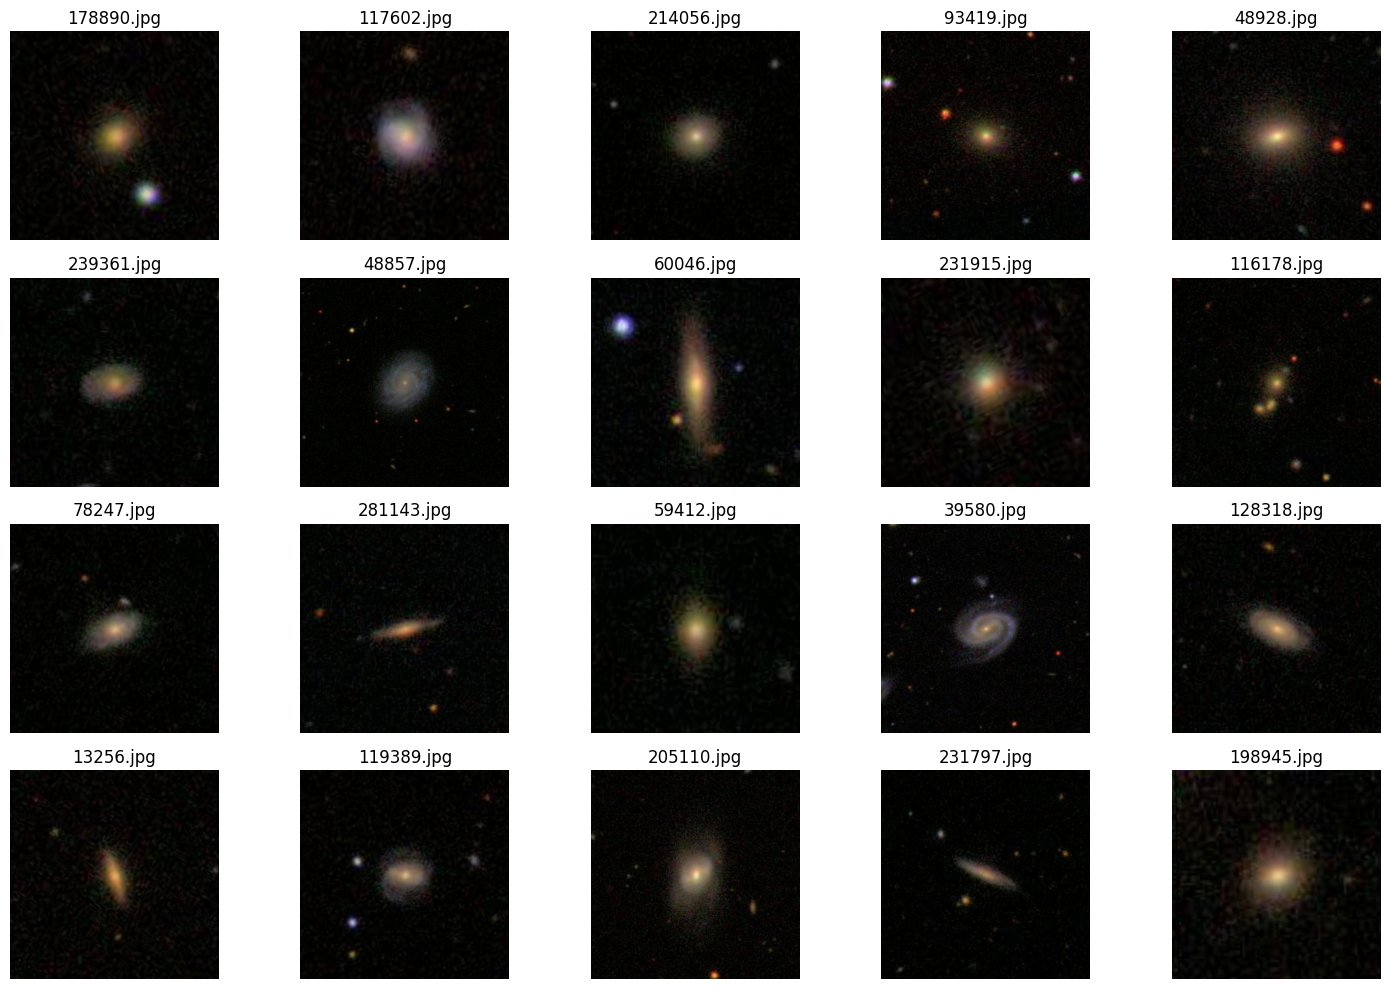

In [8]:
import random
import matplotlib.image as mpimg

# Path to your images directory
image_dir = 'images_gz2/images'  # Adjust this to your actual path

# List all image files in the directory
# Added error handling for empty image list:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
if not image_files:
    print(f"Error: No .jpg images found in directory: {image_dir}")
    # You can choose to exit here or handle it differently
    # For example, you could raise an exception or change the directory
    # exit()
else:
    # Randomly select 10 images, but limit it to the number of available images
    num_images_to_select = min(20, len(image_files))
    random_images = random.sample(image_files, num_images_to_select)

    # Set up the plot
    plt.figure(figsize=(15, 10))

    # Display each selected image
    for i, img_file in enumerate(random_images):
        img_path = os.path.join(image_dir, img_file)
        img = mpimg.imread(img_path)

        plt.subplot(4, 5, i + 1)  # Create a grid of 2 rows and 5 columns
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        plt.title(img_file)  # Show filename as title

    plt.tight_layout()
    plt.show()

![link text](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F6067505%2F8ac7df09aa0f85a1a07ac9dc0a81b57f%2FHubble_-_de_Vaucouleurs_Galaxy_Morphology_Diagram.png?generation=1611680439647479&alt=media)

In [9]:
# prompt: rad this /content/gz2_hart16.csv.gz.1 the same

import pandas as pd

try:
    morphology_data = pd.read_csv('/content/gz2_hart16.csv.gz', compression='gzip')
    morphology_data.head(10)
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
except pd.errors.ParserError:
    print("Error: Could not parse the file. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [10]:
morphology_data.shape

(239695, 231)

In [11]:
morphology_data.head(10)

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
5,587729751132209314,246.921387,40.926968,16:27:41.13,+40:55:37.1,extra,Ei,48,154,41,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
6,587733608555216981,249.474640,36.073040,16:37:53.91,+36:04:22.9,original,Ei,39,142,25,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
7,587735742617616406,243.146759,29.365067,16:12:35.22,+29:21:54.2,original,Sb+t,35,282,0,...,0.457,0.442,0.480484,0,8,8.0,0.229,0.235,0.230543,0
8,587738574068908121,195.278030,39.841473,13:01:06.73,+39:50:29.3,original,Ei,50,158,42,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
9,587731870708596837,183.062057,56.177532,12:12:14.89,+56:10:39.1,original,Sb?t,43,275,8,...,0.048,0.048,0.049229,0,9,9.0,0.429,0.429,0.426677,0


In [12]:
for i in morphology_data.columns:
  print(i)

dr7objid
ra
dec
rastring
decstring
sample
gz2_class
total_classifications
total_votes
t01_smooth_or_features_a01_smooth_count
t01_smooth_or_features_a01_smooth_weight
t01_smooth_or_features_a01_smooth_fraction
t01_smooth_or_features_a01_smooth_weighted_fraction
t01_smooth_or_features_a01_smooth_debiased
t01_smooth_or_features_a01_smooth_flag
t01_smooth_or_features_a02_features_or_disk_count
t01_smooth_or_features_a02_features_or_disk_weight
t01_smooth_or_features_a02_features_or_disk_fraction
t01_smooth_or_features_a02_features_or_disk_weighted_fraction
t01_smooth_or_features_a02_features_or_disk_debiased
t01_smooth_or_features_a02_features_or_disk_flag
t01_smooth_or_features_a03_star_or_artifact_count
t01_smooth_or_features_a03_star_or_artifact_weight
t01_smooth_or_features_a03_star_or_artifact_fraction
t01_smooth_or_features_a03_star_or_artifact_weighted_fraction
t01_smooth_or_features_a03_star_or_artifact_debiased
t01_smooth_or_features_a03_star_or_artifact_flag
t02_edgeon_a04_yes_c

In [13]:
metadata = pd.read_csv('/content/gz2_filename_mapping.csv')


In [14]:
metadata.head(10)

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5
5,587722981741625481,original,6
6,587722981741625484,original,7
7,587722981741625520,original,8
8,587722981741625545,original,9
9,587722981741691055,original,10


In [15]:

images=os.listdir(image_dir)
image_count = len(images)
print(f"Total number of images in {image_dir}: {image_count}")

Total number of images in images_gz2/images: 243437


In [16]:
sample_unique = metadata["sample"].nunique()
print(f"Total number of unique samples: {sample_unique}")
metadata["sample"].value_counts()

Total number of unique samples: 5


,count
sample,
original,245609
stripe82_coadd_1,30346
stripe82_coadd_2,30339
extra,28174
stripe82,21522


In [17]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355990 entries, 0 to 355989
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   objid     355990 non-null  int64 
 1   sample    355990 non-null  object
 2   asset_id  355990 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 8.1+ MB


In [18]:
metadata.describe().T # Not very much useful here

,count,mean,std,min,25%,50%,75%,max
objid,355990.0,1.961733e+18,3.030788e+18,5.877230e+17,5.877334e+17,5.877399e+17,5.880177e+17,8.647475e+18
asset_id,355990.0,1.779955e+05,1.027656e+05,1.000000e+00,8.899825e+04,1.779955e+05,2.669928e+05,3.559900e+05


In [19]:
# Check for missing values
print(metadata.isnull().sum())
print("-" * 20)

# Explore data types and unique values for each column
for col in metadata.columns:
    print(f"Column: {col}")
    print(f"Data type: {metadata[col].dtype}")
    print(f"Number of unique values: {metadata[col].nunique()}")
    print(f"Unique values: {metadata[col].unique()[:10]}") # Show first 10 unique values
    print("-" * 20)

objid       0
sample      0
asset_id    0
dtype: int64
--------------------
Column: objid
Data type: int64
Number of unique values: 325651
Unique values: [587722981736120347 587722981736579107 587722981741363294
 587722981741363323 587722981741559888 587722981741625481
 587722981741625484 587722981741625520 587722981741625545
 587722981741691055]
--------------------
Column: sample
Data type: object
Number of unique values: 5
Unique values: ['original' 'extra' 'stripe82' 'stripe82_coadd_1' 'stripe82_coadd_2']
--------------------
Column: asset_id
Data type: int64
Number of unique values: 355990
Unique values: [ 1  2  3  4  5  6  7  8  9 10]
--------------------


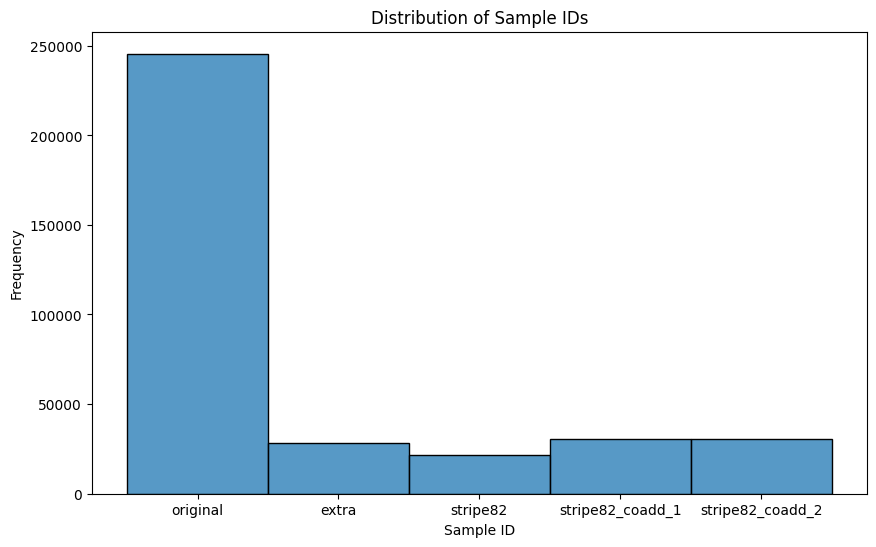

In [20]:
# Analyze the distribution of 'sample' values (if it represents galaxy IDs or something similar)
plt.figure(figsize=(10, 6))
sns.histplot(metadata['sample'], bins=30) # Adjust the number of bins as needed
plt.title('Distribution of Sample IDs')
plt.xlabel('Sample ID')
plt.ylabel('Frequency')
plt.show()

In [21]:
# If 'object_id' is a unique identifier for each galaxy, examine its distribution
if 'object_id' in metadata.columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(metadata['object_id'], bins=30)
  plt.title('Distribution of Object IDs')
  plt.xlabel('Object ID')
  plt.ylabel('Frequency')
  plt.show()


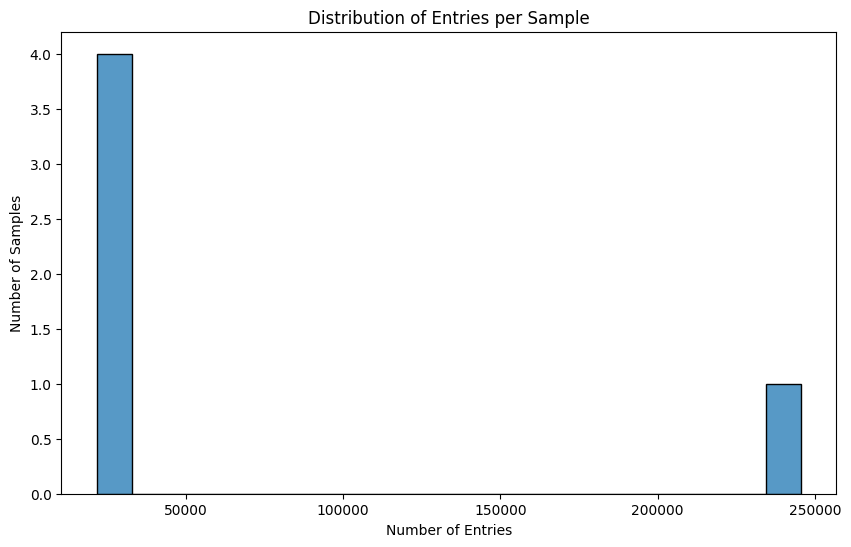

count         5.000000
mean      71198.000000
std       97565.760206
min       21522.000000
25%       28174.000000
50%       30339.000000
75%       30346.000000
max      245609.000000
Name: sample, dtype: float64


In [22]:
# Example: Count the number of entries per sample
entries_per_sample = metadata.groupby('sample')['sample'].count() # Count occurrences of 'sample' values

plt.figure(figsize=(10, 6))
sns.histplot(entries_per_sample, bins=20)
plt.title('Distribution of Entries per Sample') # Changed title
plt.xlabel('Number of Entries') # Changed x-axis label
plt.ylabel('Number of Samples')
plt.show()

print(entries_per_sample.describe())


In [23]:
metadata["objid"].value_counts()

,count
objid,
8647475122541625762,2
8647474693020451479,2
8647474693020319805,2
8647474693020319806,2
8647474693020319847,2
...,...
587738067811696777,1
587738067811696759,1
587738067811565671,1


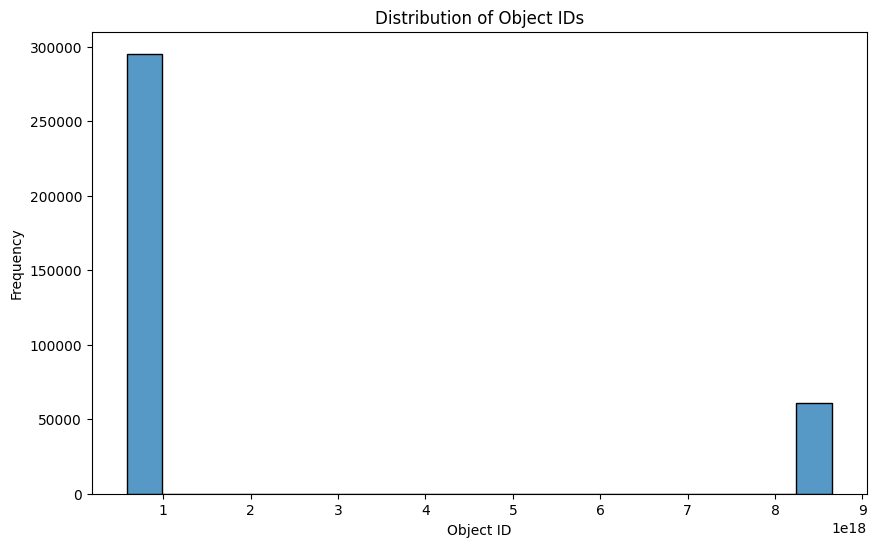

In [24]:
# Assuming 'objid' is a column in your 'file_map' DataFrame

plt.figure(figsize=(10, 6))
sns.histplot(metadata['objid'], bins=20)  # Adjust the number of bins as needed
plt.title('Distribution of Object IDs')
plt.xlabel('Object ID')
plt.ylabel('Frequency')
plt.show()

In [25]:
# prompt: replace name of objid column

# Rename the 'dr7objid' column to 'objid' in the morphology_data DataFrame
morphology_data = morphology_data.rename(columns={'dr7objid': 'objid'})
morphology_data



,objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239690,587741490371625059,167.542648,28.991867,11:10:10.23,+28:59:30.7,extra,Ec,42,135,34,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
239691,587731174917669027,316.108826,1.214799,21:04:26.12,+01:12:53.3,stripe82,Ei(i),46,186,25,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
239692,587731512070177108,21.690212,-0.546427,01:26:45.65,+00:32:47.1,stripe82,Ei,48,164,36,...,0.000,0.000,0.000000,0,2,2.0,1.000,1.000,1.000000,1
239693,587731513145688256,25.747143,0.360079,01:42:59.31,+00:21:36.3,stripe82,Ei(i),48,204,25,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [26]:
# Merge the two datasets on 'objid'
merged_data = pd.merge(metadata, morphology_data, on='objid', how='inner')

# Check the merged data
merged_data.head()


,objid,sample_x,asset_id,ra,dec,rastring,decstring,sample_y,gz2_class,total_classifications,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587722981741363294,original,3,182.925262,-1.092357,12:11:42.06,-01:05:32.5,original,Sb,52,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
1,587722981741363323,original,4,182.970108,-1.219537,12:11:52.83,-01:13:10.3,original,Sc?l,30,...,0.0,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1
2,587722981741559888,original,5,183.438095,-1.238414,12:13:45.14,-01:14:18.3,original,Er,53,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
3,587722981741625481,original,6,183.473999,-1.231429,12:13:53.76,-01:13:53.1,original,Sc1t,37,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
4,587722981741625484,original,7,183.477783,-1.084604,12:13:54.67,-01:05:04.6,original,Sb,45,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


In [27]:
for i in merged_data.columns:
  print(i)

objid
sample_x
asset_id
ra
dec
rastring
decstring
sample_y
gz2_class
total_classifications
total_votes
t01_smooth_or_features_a01_smooth_count
t01_smooth_or_features_a01_smooth_weight
t01_smooth_or_features_a01_smooth_fraction
t01_smooth_or_features_a01_smooth_weighted_fraction
t01_smooth_or_features_a01_smooth_debiased
t01_smooth_or_features_a01_smooth_flag
t01_smooth_or_features_a02_features_or_disk_count
t01_smooth_or_features_a02_features_or_disk_weight
t01_smooth_or_features_a02_features_or_disk_fraction
t01_smooth_or_features_a02_features_or_disk_weighted_fraction
t01_smooth_or_features_a02_features_or_disk_debiased
t01_smooth_or_features_a02_features_or_disk_flag
t01_smooth_or_features_a03_star_or_artifact_count
t01_smooth_or_features_a03_star_or_artifact_weight
t01_smooth_or_features_a03_star_or_artifact_fraction
t01_smooth_or_features_a03_star_or_artifact_weighted_fraction
t01_smooth_or_features_a03_star_or_artifact_debiased
t01_smooth_or_features_a03_star_or_artifact_flag
t02

In [28]:
relevant_columns = [
    'objid','sample_x', 'asset_id',
    't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a02_features_or_disk_debiased',
    't02_edgeon_a04_yes_debiased', 't02_edgeon_a05_no_debiased',
    't03_bar_a06_bar_debiased', 't03_bar_a07_no_bar_debiased',
    't04_spiral_a08_spiral_debiased', 't04_spiral_a09_no_spiral_debiased',
    't05_bulge_prominence_a10_no_bulge_debiased', 't05_bulge_prominence_a12_obvious_debiased'
]


In [29]:
# Filter the relevant columns for classification
filtered_data = merged_data[relevant_columns]

In [30]:
filtered_data.sample(10)

,objid,sample_x,asset_id,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t02_edgeon_a04_yes_debiased,t02_edgeon_a05_no_debiased,t03_bar_a06_bar_debiased,t03_bar_a07_no_bar_debiased,t04_spiral_a08_spiral_debiased,t04_spiral_a09_no_spiral_debiased,t05_bulge_prominence_a10_no_bulge_debiased,t05_bulge_prominence_a12_obvious_debiased
159583,587745402533642604,original,187372,0.045,0.945,0.025323,0.917114,0.697075,0.174723,0.974213,0.000989,0.048341,0.230542
73698,587735697523998813,original,87334,0.249,0.730,0.000000,1.000000,0.000000,1.000000,0.688664,0.233645,0.146479,0.000000
163589,588009365861171261,original,192963,0.836,0.087,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
49129,587732701786734820,original,59499,0.171,0.854,0.002052,0.966820,0.186661,0.749446,0.988553,0.000648,0.000000,0.530743
222139,587739828200997034,extra,262122,0.027,0.919,0.000000,1.000000,0.000000,1.000000,0.999407,0.000574,0.227345,0.000000
24132,587729156281466976,original,30021,0.023,0.976,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
121813,587739827132956816,original,142494,0.688,0.421,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.580896
46441,587732576702103687,original,56479,0.000,0.986,0.000790,0.963910,0.074995,0.870856,0.995651,0.000002,0.000000,0.691208
57287,587733429234499700,original,68537,0.848,0.111,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.427228
171586,588013382187810918,original,203322,0.900,0.026,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000


In [31]:
filtered_data.shape

(239695, 13)

In [32]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239695 entries, 0 to 239694
Data columns (total 13 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   objid                                                 239695 non-null  int64  
 1   sample_x                                              239695 non-null  object 
 2   asset_id                                              239695 non-null  int64  
 3   t01_smooth_or_features_a01_smooth_debiased            239695 non-null  float64
 4   t01_smooth_or_features_a02_features_or_disk_debiased  239695 non-null  float64
 5   t02_edgeon_a04_yes_debiased                           239695 non-null  float64
 6   t02_edgeon_a05_no_debiased                            239401 non-null  float64
 7   t03_bar_a06_bar_debiased                              239695 non-null  float64
 8   t03_bar_a07_no_bar_debiased                 

In [33]:
filtered_data.describe().T

,count,mean,std,min,25%,50%,75%,max
objid,239695.0,5.878182e+17,1.827461e+14,5.877230e+17,5.877327e+17,5.877393e+17,5.877429e+17,5.888489e+17
asset_id,239695.0,1.418400e+05,8.152236e+04,3.000000e+00,7.161950e+04,1.402870e+05,2.124575e+05,2.953050e+05
t01_smooth_or_features_a01_smooth_debiased,239695.0,3.979425e-01,3.464840e-01,0.000000e+00,4.000000e-02,3.260000e-01,7.760000e-01,1.000000e+00
t01_smooth_or_features_a02_features_or_disk_debiased,239695.0,5.924470e-01,3.620481e-01,0.000000e+00,1.810000e-01,6.920000e-01,9.530000e-01,1.000000e+00
t02_edgeon_a04_yes_debiased,239695.0,1.381704e-01,2.798277e-01,0.000000e+00,0.000000e+00,0.000000e+00,9.145935e-02,1.000000e+00
t02_edgeon_a05_no_debiased,239401.0,8.517421e-01,2.757892e-01,0.000000e+00,8.584243e-01,1.000000e+00,1.000000e+00,1.000000e+00
t03_bar_a06_bar_debiased,239695.0,2.539545e-01,3.327718e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00
t03_bar_a07_no_bar_debiased,239415.0,6.712325e-01,3.848734e-01,0.000000e+00,3.187328e-01,8.815335e-01,1.000000e+00,1.000000e+00
t04_spiral_a08_spiral_debiased,239695.0,4.980884e-01,4.559295e-01,0.000000e+00,0.000000e+00,5.828205e-01,9.890564e-01,1.000000e+00
t04_spiral_a09_no_spiral_debiased,239407.0,4.444128e-01,4.584062e-01,0.000000e+00,2.058668e-06,2.109837e-01,1.000000e+00,1.000000e+00


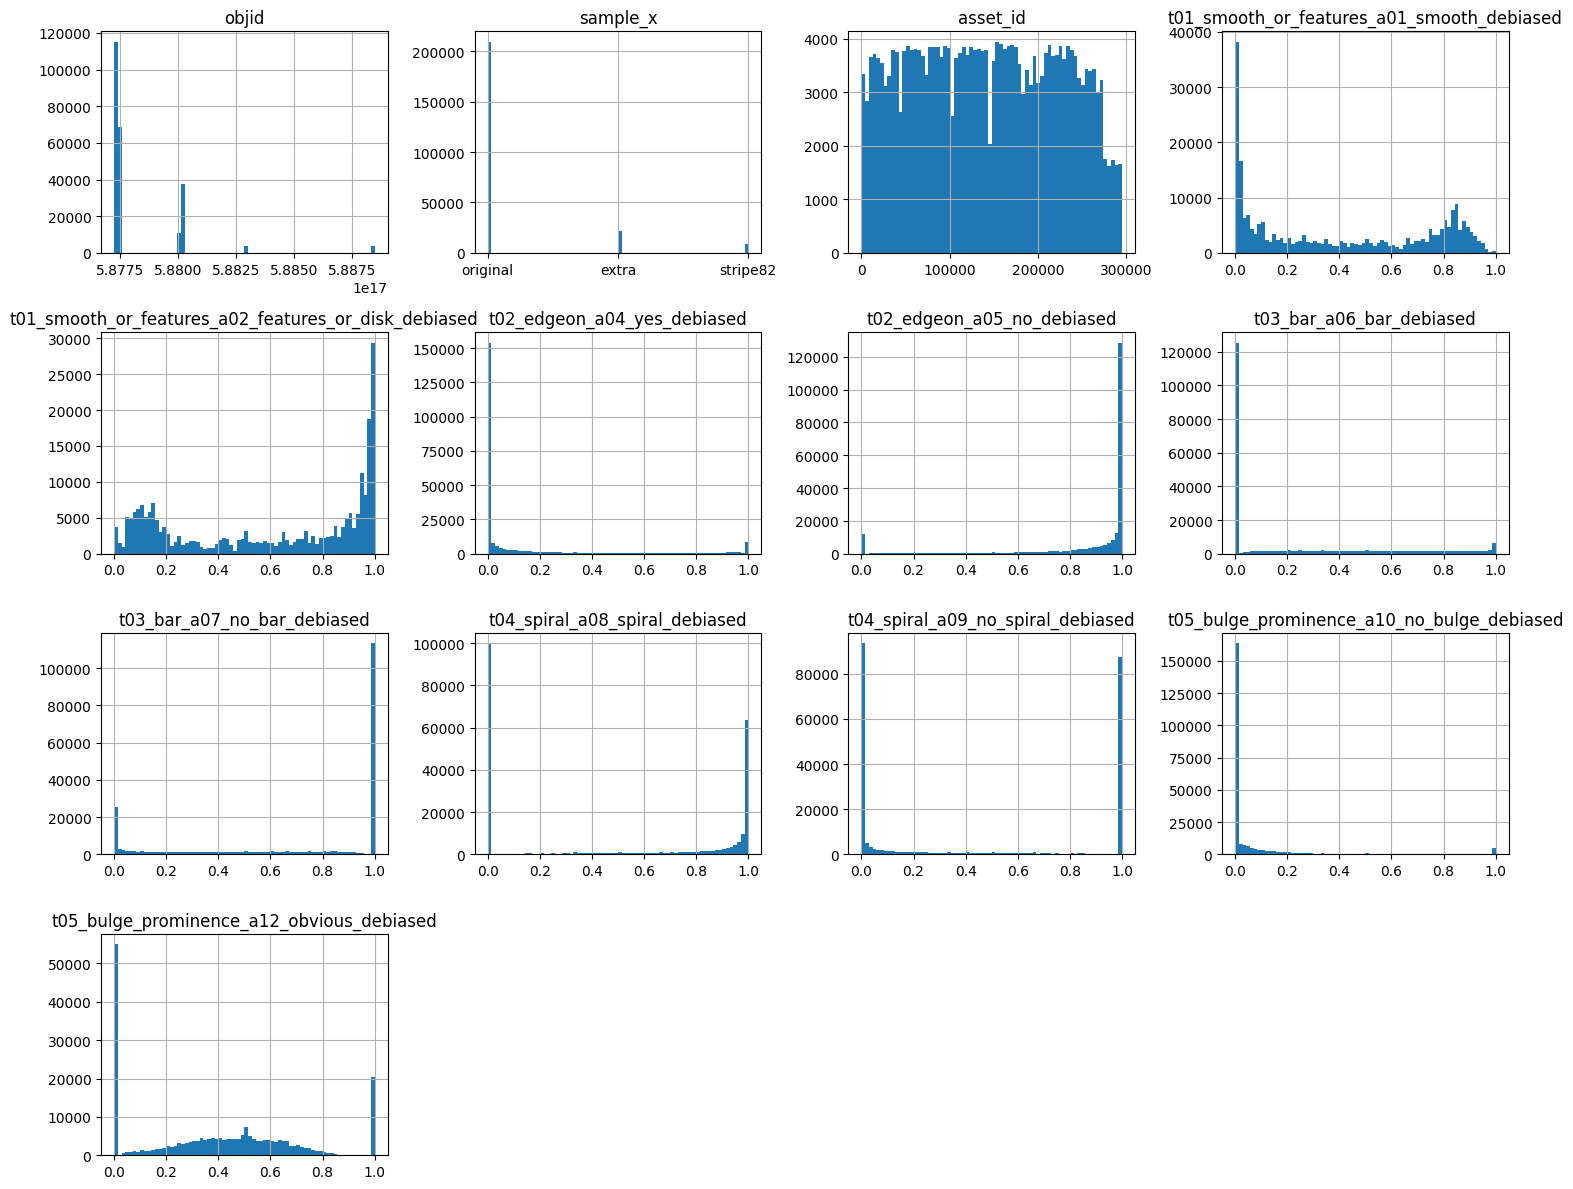

In [34]:
num_cols = 4  # Number of columns in the subplot grid
num_rows = (len(relevant_columns) + num_cols - 1) // num_cols # Calculate the number of rows

plt.figure(figsize=(15, 3 * num_rows)) # Adjust figure size based on the number of rows

for i, col in enumerate(relevant_columns):
    plt.subplot(num_rows, num_cols, i + 1)
    merged_data[col].hist(bins=70)
    plt.title(col)

plt.tight_layout()
plt.show()

In [35]:
original_sample = merged_data[merged_data['sample_x'] == 'original']
extra_sample = merged_data[merged_data['sample_x'] == 'extra']

original_sample.shape, extra_sample.shape

((209294, 233), (21844, 233))

In [36]:
smooth_galaxies = merged_data[merged_data['t01_smooth_or_features_a01_smooth_debiased'] > 0.5]
disk_galaxies = merged_data[merged_data['t01_smooth_or_features_a02_features_or_disk_debiased'] > 0.5]

smooth_galaxies.shape, disk_galaxies.shape



((97575, 233), (141678, 233))

In [37]:
spiral_galaxies = merged_data[merged_data['t04_spiral_a08_spiral_debiased'] > 0.5]
non_spiral_galaxies = merged_data[merged_data['t04_spiral_a09_no_spiral_debiased'] > 0.5]

spiral_galaxies.shape, non_spiral_galaxies.shape


((123740, 233), (102917, 233))

In [38]:
edge_on_galaxies = merged_data[merged_data['t02_edgeon_a04_yes_debiased'] > 0.5]
non_edge_on_galaxies = merged_data[merged_data['t02_edgeon_a05_no_debiased'] > 0.5]

edge_on_galaxies.shape, non_edge_on_galaxies.shape

((28952, 233), (210806, 233))

In [39]:
barred_galaxies = merged_data[merged_data['t03_bar_a06_bar_debiased'] > 0.5]
non_barred_galaxies = merged_data[merged_data['t03_bar_a07_no_bar_debiased'] > 0.5]

barred_galaxies.shape, non_barred_galaxies.shape

((59551, 233), (160883, 233))

In [40]:
no_bulge_galaxies = merged_data[merged_data['t05_bulge_prominence_a10_no_bulge_debiased'] > 0.5]
obvious_bulge_galaxies = merged_data[merged_data['t05_bulge_prominence_a12_obvious_debiased'] > 0.5]

no_bulge_galaxies.shape, obvious_bulge_galaxies.shape

((9335, 233), (89710, 233))

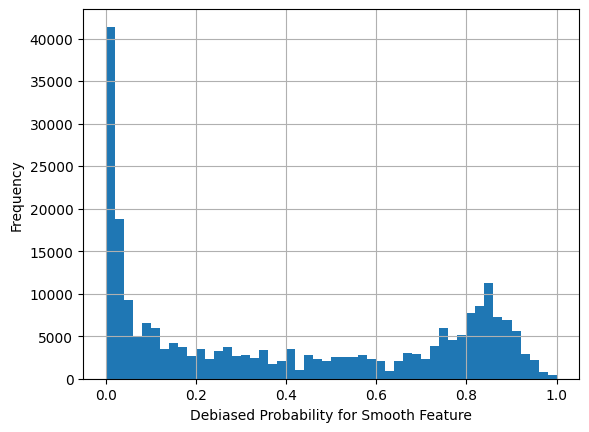

In [41]:
import matplotlib.pyplot as plt
merged_data['t01_smooth_or_features_a01_smooth_debiased'].hist(bins=50)
plt.xlabel('Debiased Probability for Smooth Feature')
plt.ylabel('Frequency')
plt.show()


In [42]:
# Define a threshold for classification
threshold = 0.7

# Create new columns based on thresholds
merged_data['classification'] = merged_data.apply(lambda row:
    'Smooth' if row['t01_smooth_or_features_a01_smooth_debiased'] > threshold else
    'Disk-Feature' if row['t01_smooth_or_features_a02_features_or_disk_debiased'] > threshold else
    'Edge-on' if row['t02_edgeon_a04_yes_debiased'] > threshold else
    'Bar' if row['t03_bar_a06_bar_debiased'] > threshold else
    'Spiral' if row['t04_spiral_a08_spiral_debiased'] > threshold else
    'Unknown', axis=1)




In [43]:
# Inspect resulting classifications
merged_data[['objid', 'classification', 'asset_id']].sample(10)

,objid,classification,asset_id
168010,588010879292145735,Disk-Feature,198086
54406,587733195697487910,Disk-Feature,65338
177980,588017569773650036,Disk-Feature,210449
196338,588017991773651124,Smooth,231109
223056,587741603095904407,Disk-Feature,263490
204586,588297865252700330,Disk-Feature,240267
166935,588010360151146832,Disk-Feature,196892
185012,588017704027816291,Spiral,218323
224783,587742567856078982,Unknown,265442
147233,587742551221272653,Smooth,172527


In [44]:
merged_data['classification'].value_counts()

,count
classification,
Disk-Feature,114554
Smooth,75459
Unknown,27805
Spiral,11426
Edge-on,6345
Bar,4106


In [45]:
unknown_galaxies = merged_data[merged_data['classification'] == 'Unknown']
unknown_galaxies.shape

(27805, 234)

In [46]:
unknown_galaxies.sample(10)

,objid,sample_x,asset_id,ra,dec,rastring,decstring,sample_y,gz2_class,total_classifications,...,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag,classification
106957,587739406233960620,original,125928,154.594971,30.401070,10:18:22.79,+30:24:03.9,original,Er,43,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
54394,587733195697094834,original,65324,195.508026,53.988064,13:02:01.93,+53:59:17.0,original,Sb,41,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
146165,587742191527395372,original,171379,213.913834,23.229988,14:15:39.32,+23:13:48.0,original,Sc(o),43,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
132462,587741708348686464,original,156375,181.693192,27.000492,12:06:46.37,+27:00:01.8,original,Ei,36,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
81955,587736753005396250,original,96560,242.032532,33.021149,16:08:07.81,+33:01:16.1,original,Sc,51,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
175492,588017109686878276,original,207604,189.199341,46.259239,12:36:47.84,+46:15:33.3,original,Sb,41,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
127720,587741491448643662,original,151277,176.099045,30.732203,11:44:23.77,+30:43:55.9,original,Er,43,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
83643,587736808840560852,original,98440,212.672287,13.557996,14:10:41.35,+13:33:28.8,original,Sb3t(d),41,...,0.0,0.0,0,5,5.0,0.333,0.333,0.333,0,Unknown
38005,587731870706761849,original,47141,175.414734,55.865353,11:41:39.54,+55:51:55.3,original,Ei,41,...,0.0,0.0,0,0,0.0,0.000,0.000,0.000,0,Unknown
214644,587732771595550843,extra,252893,189.836533,10.124636,12:39:20.77,+10:07:28.7,extra,Ec,32,...,0.0,0.0,0,1,1.0,0.500,0.500,0.500,0,Unknown


In [47]:
unknown_galaxies[relevant_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
objid,27805.0,5.878185e+17,1.832006e+14,5.877230e+17,5.877327e+17,5.877392e+17,5.877429e+17,5.888489e+17
asset_id,27805.0,1.421427e+05,8.182316e+04,3.000000e+00,7.178200e+04,1.393040e+05,2.139530e+05,2.952300e+05
t01_smooth_or_features_a01_smooth_debiased,27805.0,4.539268e-01,1.730647e-01,0.000000e+00,3.420000e-01,4.860000e-01,5.850000e-01,7.000000e-01
t01_smooth_or_features_a02_features_or_disk_debiased,27805.0,3.877207e-01,1.874018e-01,0.000000e+00,2.210000e-01,4.150000e-01,5.390000e-01,7.000000e-01
t02_edgeon_a04_yes_debiased,27805.0,9.823031e-02,1.720561e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.163636e-01,7.000000e-01
t02_edgeon_a05_no_debiased,27732.0,8.999982e-01,1.703519e-01,0.000000e+00,8.640000e-01,1.000000e+00,1.000000e+00,1.000000e+00
t03_bar_a06_bar_debiased,27805.0,1.109320e-01,1.884553e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.722491e-01,7.000000e-01
t03_bar_a07_no_bar_debiased,27732.0,8.758488e-01,2.146165e-01,0.000000e+00,8.098610e-01,1.000000e+00,1.000000e+00,1.000000e+00
t04_spiral_a08_spiral_debiased,27805.0,1.658368e-01,2.329501e-01,0.000000e+00,0.000000e+00,0.000000e+00,3.495997e-01,7.000000e-01
t04_spiral_a09_no_spiral_debiased,27733.0,8.198828e-01,2.534937e-01,0.000000e+00,6.268891e-01,1.000000e+00,1.000000e+00,1.000000e+00


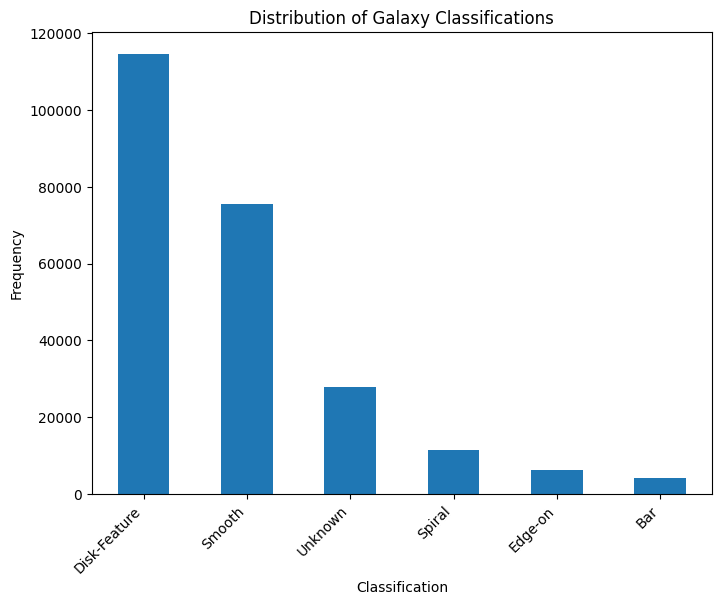

In [48]:
# Visualize the distribution of the 'Unknown' classification
plt.figure(figsize=(8, 6))
merged_data['classification'].value_counts().plot(kind='bar')
plt.title('Distribution of Galaxy Classifications')
plt.xlabel('Classification')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.show()

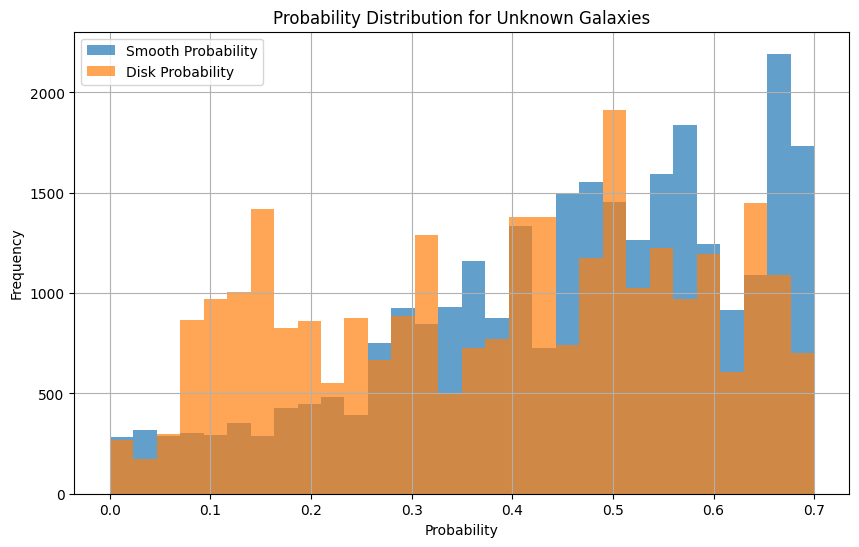

In [49]:
#Further analysis of 'Unknown' galaxies
unknown_galaxies = merged_data[merged_data['classification'] == 'Unknown']

# Example:  Look at the distribution of probabilities for unknown galaxies for a specific feature
plt.figure(figsize=(10, 6))
unknown_galaxies['t01_smooth_or_features_a01_smooth_debiased'].hist(bins=30, alpha=0.7, label='Smooth Probability')
unknown_galaxies['t01_smooth_or_features_a02_features_or_disk_debiased'].hist(bins=30, alpha=0.7, label='Disk Probability')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Probability Distribution for Unknown Galaxies')
plt.legend()
plt.show()

In [50]:
id_n_cl = merged_data[['asset_id','classification']]
id_n_cl.head(10)

,asset_id,classification
0,3,Unknown
1,4,Disk-Feature
2,5,Smooth
3,6,Unknown
4,7,Disk-Feature
5,8,Smooth
6,9,Smooth
7,11,Disk-Feature
8,12,Unknown
9,13,Spiral


In [51]:


# Paths to images and where to store organized folders
image_dir = '/content/images_gz2/images'  # Your image directory
output_dir = '/content/output/train/'  # Directory to store organized folders

# Create class folders if they do not exist
classes = id_n_cl['classification'].unique()
for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

# Move images to their respective class folders
for index, row in id_n_cl.iterrows():
    asset_id = row['asset_id']
    classification = row['classification']
    image_name = f"{asset_id}.jpg"  # Assuming images are named by asset_id
    source = os.path.join(image_dir, image_name)
    destination = os.path.join(output_dir, classification, image_name)

    # Move the file if it exists
    if os.path.exists(source):
        shutil.move(source, destination)
    else:
        print(f"Image {image_name} not found.")


Image 374.jpg not found.
Image 7349.jpg not found.
Image 7350.jpg not found.
Image 7351.jpg not found.
Image 10959.jpg not found.
Image 15246.jpg not found.
Image 15247.jpg not found.
Image 26603.jpg not found.
Image 26606.jpg not found.
Image 27513.jpg not found.
Image 27514.jpg not found.
Image 30336.jpg not found.
Image 33876.jpg not found.
Image 33877.jpg not found.
Image 33878.jpg not found.
Image 40057.jpg not found.
Image 50643.jpg not found.
Image 59269.jpg not found.
Image 59270.jpg not found.
Image 59271.jpg not found.
Image 81483.jpg not found.
Image 89792.jpg not found.
Image 92317.jpg not found.
Image 95667.jpg not found.
Image 99869.jpg not found.
Image 99870.jpg not found.
Image 102663.jpg not found.
Image 102665.jpg not found.
Image 191283.jpg not found.
Image 198040.jpg not found.
Image 198041.jpg not found.
Image 198345.jpg not found.
Image 198346.jpg not found.
Image 198347.jpg not found.
Image 198348.jpg not found.
Image 198349.jpg not found.
Image 198350.jpg not fo

In [52]:
train_dir = '/content/output/train/'

# Dictionary to store counts
class_counts = {}

# Iterate through subdirectories (classes) in the train directory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    # Check if it is a directory
    if os.path.isdir(class_path):
        # Count the number of image files in the class directory
        image_count = sum(1 for filename in os.listdir(class_path) if filename.endswith(('.jpg', '.jpeg', '.png'))) # Add more extensions as needed
        class_counts[class_name] = image_count
        print(f"Class: {class_name}, Number of images: {image_count}")

# Print total counts if needed
#print("\nTotal image counts per class:")
#for class_name, count in class_counts.items():
#    print(f"{class_name}: {count}")

Class: Unknown, Number of images: 27746
Class: Edge-on, Number of images: 6336
Class: Spiral, Number of images: 11421
Class: Bar, Number of images: 4102
Class: Disk-Feature, Number of images: 114525
Class: Smooth, Number of images: 75443


In [53]:
# Print total counts if needed
print("\nTotal image counts per class:")
for class_name, count in class_counts.items():
   print(f"{class_name}: {count}")


Total image counts per class:
Unknown: 27746
Edge-on: 6336
Spiral: 11421
Bar: 4102
Disk-Feature: 114525
Smooth: 75443


In [54]:
# prompt: delete output folder

# import shutil

# shutil.rmtree('/content/output', ignore_errors=True)

In [55]:

from collections import defaultdict

def balance_classes(source_dir, destination_dir, max_per_class=2000):
    """Balances image classes by taking a maximum number of images from each class."""

    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

    class_counts = defaultdict(int)
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if os.path.isdir(class_path):
            for image_name in os.listdir(class_path):
                if class_counts[class_name] < max_per_class:
                    source_image_path = os.path.join(class_path, image_name)
                    destination_class_path = os.path.join(destination_dir, class_name)
                    if not os.path.exists(destination_class_path):
                        os.makedirs(destination_class_path)

                    destination_image_path = os.path.join(destination_class_path, image_name)
                    shutil.copy2(source_image_path, destination_image_path) # copy2 preserves metadata
                    class_counts[class_name] += 1


# Example usage (assuming your balanced data will go into model_data)
source_directory = '/content/output/train'  # Replace with the actual path
destination_directory = '/content/model_data'
balance_classes(source_directory, destination_directory)

In [56]:
# prompt: arrange images in train test and val folders, with 70,15, 15 percent split ration

import os
import shutil
import random

def split_data(source_dir, train_dir, test_dir, val_dir, train_ratio=0.7, test_ratio=0.15, val_ratio=0.15):
    """Splits data into train, test, and validation sets."""

    if not os.path.exists(train_dir):
        os.makedirs(train_dir)
    if not os.path.exists(test_dir):
        os.makedirs(test_dir)
    if not os.path.exists(val_dir):
        os.makedirs(val_dir)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            random.shuffle(images)
            num_images = len(images)

            num_train = int(train_ratio * num_images)
            num_test = int(test_ratio * num_images)
            num_val = int(val_ratio * num_images)

            train_images = images[:num_train]
            test_images = images[num_train:num_train + num_test]
            val_images = images[num_train + num_test:num_train + num_test + num_val]


            for image in train_images:
                source = os.path.join(class_path, image)
                destination = os.path.join(train_dir, class_name, image)
                os.makedirs(os.path.dirname(destination), exist_ok=True)
                shutil.copy2(source, destination)  # Copy file (preserves metadata)

            for image in test_images:
                source = os.path.join(class_path, image)
                destination = os.path.join(test_dir, class_name, image)
                os.makedirs(os.path.dirname(destination), exist_ok=True)
                shutil.copy2(source, destination)

            for image in val_images:
                source = os.path.join(class_path, image)
                destination = os.path.join(val_dir, class_name, image)
                os.makedirs(os.path.dirname(destination), exist_ok=True)
                shutil.copy2(source, destination)


# Example usage
source_directory = '/content/model_data'
train_directory = '/content/galaxy_data/train'
test_directory = '/content/galaxy_data/test'
validation_directory = '/content/galaxy_data/validation'


split_data(source_directory, train_directory, test_directory, validation_directory)

In [57]:
%pip install torch==2.0.0 torchvision==0.15.0

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch==2.0.0 and torchvision==0.15.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch==2.0.0
    torchvision 0.15.0 depends on torch==2.0.0+cu117

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [58]:
%pip install torchsummary

In [59]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.5.0+cu121
0.20.0+cu121


# Image Resizing
**Target Dimensions:** Resize images to **224x224** pixels to match input size requirements for the CNN.

**Image Preprocessing:** Apply the following transformations for data augmentation and normalization:
 - **Training Set:** Random rotation, random horizontal flip, resize to 224x224, and normalization (mean and std for each color channel).
 - **Validation Set:** Resize to 224x224 and normalization only

In [60]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize images if needed
    transforms.ToTensor(),           # Convert to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Define datasets
train_dataset = datasets.ImageFolder(root=train_directory, transform=transform)
val_dataset = datasets.ImageFolder(root=validation_directory, transform=transform)
test_dataset = datasets.ImageFolder(root=test_directory, transform=transform)

# Create DataLoader for training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Access the class-to-index mapping
class_to_idx_train = train_dataset.class_to_idx
class_to_idx_val = val_dataset.class_to_idx
class_to_idx_test = test_dataset.class_to_idx

print(class_to_idx_train)  # {'Bar': 0, 'Disk_Feature': 1, 'Edge_on': 2, 'Smooth': 3, 'Spiral': 4, 'Unknown': 5}


{'Bar': 0, 'Disk-Feature': 1, 'Edge-on': 2, 'Smooth': 3, 'Spiral': 4, 'Unknown': 5}





### 2. **Building the Model Architecture**

The model is a custom CNN architecture designed to classify galaxy images with regularization layers to prevent overfitting. Here’s how the dimensions change as images pass through each layer.

#### Model Layers and Dimension Flow

1. **Input Layer**: `224x224x3` (RGB image)

2. **Convolutional and Pooling Layers**
    - **Conv1**: `3x3` kernel, `16` filters, stride `1`, padding `1`
        - **Output**: `224x224x16` (16 feature maps)
    - **MaxPooling**: `2x2` kernel, stride `2`
        - **Output**: `112x112x16`
    - **Dropout**: `p=0.5`

    - **Conv2**: `3x3` kernel, `32` filters, stride `1`, padding `1`
        - **Output**: `112x112x32`
    - **MaxPooling**: `2x2` kernel, stride `2`
        - **Output**: `56x56x32`
    - **Dropout**: `p=0.5`

    - **Conv3**: `3x3` kernel, `64` filters, stride `1`, padding `1`
        - **Output**: `56x56x64`
    - **MaxPooling**: `2x2` kernel, stride `2`
        - **Output**: `28x28x64`
    - **Dropout**: `p=0.5`

3. **Adaptive Average Pooling Layer**
   - **AdaptiveAvgPool2d(7,7)**: Reduces `28x28x64` to `7x7x64` by averaging across areas to create a fixed size output.
     - **Output**: `7x7x64`

4. **Fully Connected Layers**
    - **Flattening**: Converts `7x7x64` to a 1D vector of size `3136` (`7*7*64=3136`).
    - **Fully Connected Layer 1**: Input `3136`, Output `256`
    - **Dropout**: `p=0.5`
    - **Fully Connected Layer 2**: Output `num_classes`

---


In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedCNN, self).__init__()

        # Convolutional Layers with BatchNorm
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # Adaptive Pooling to produce a consistent size
        self.avg_pool = nn.AdaptiveAvgPool2d((7, 7))  # (7, 7) is arbitrary and can be adjusted as needed

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 7 * 7, 256)  # Match this with output of avg_pool
        self.fc2 = nn.Linear(256, num_classes)

        # Dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Convolutional layers with ReLU, BatchNorm, MaxPooling, and Dropout
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)

        # Adaptive pooling
        x = self.avg_pool(x)

        # Flatten and pass through fully connected layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Instantiate the regularized model
num_classes = len(train_dataset.classes)  # Adjust based on your classes
model = RegularizedCNN(num_classes)


In [62]:
num_classes, model

(6,
 RegularizedCNN(
   (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (avg_pool): AdaptiveAvgPool2d(output_size=(7, 7))
   (fc1): Linear(in_features=3136, out_features=256, bias=True)
   (fc2): Linear(in_features=256, out_features=6, bias=True)
   (dropout): Dropout(p=0.5, inplace=False)
 ))

In [63]:
from torchsummary import summary

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print the model summary (assuming input size of 224x224 with 3 channels for RGB images)
summary(model, input_size=(3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
       BatchNorm2d-2         [-1, 16, 224, 224]              32
           Dropout-3         [-1, 16, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]           4,640
       BatchNorm2d-5         [-1, 32, 112, 112]              64
           Dropout-6           [-1, 32, 56, 56]               0
            Conv2d-7           [-1, 64, 56, 56]          18,496
       BatchNorm2d-8           [-1, 64, 56, 56]             128
           Dropout-9           [-1, 64, 28, 28]               0
AdaptiveAvgPool2d-10             [-1, 64, 7, 7]               0
           Linear-11                  [-1, 256]         803,072
          Dropout-12                  [-1, 256]               0
           Linear-13                    [-1, 6]           1,542
Total params: 828,422
Trainable params:

In [64]:
criterion = nn.CrossEntropyLoss()


In [65]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [66]:
from tqdm import tqdm  # Import tqdm for progress bars

# Training function
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training", leave=False)  # Progress bar for training

    for images, labels in progress_bar:
        # Move data to the GPU (if available)
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Zero the gradients before the backward pass
        optimizer.zero_grad()

        # Backward pass: Compute gradients
        loss.backward()

        # Update the weights
        optimizer.step()

        # Accumulate the loss
        running_loss += loss.item()

        # Update the progress bar
        progress_bar.set_postfix({"loss": loss.item()})

    # Return the average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    return avg_loss

In [67]:
# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    progress_bar = tqdm(val_loader, desc="Validating", leave=False)  # Progress bar for validation

    with torch.no_grad():
        for images, labels in progress_bar:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Get predictions and calculate accuracy
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)

            # Update the progress bar
            progress_bar.set_postfix({"val_loss": loss.item()})

    # Calculate average loss and accuracy
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct.double() / len(val_loader.dataset)

    return avg_val_loss, val_acc

In [68]:
# Initialize lists to store losses
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    best_val_acc = 0.0  # Track best validation accuracy

    for epoch in range(num_epochs):
        print(f'Epoch [{epoch+1}/{num_epochs}]')

        # Train for one epoch
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss) # Append train loss for the epoch
        print(f'Train Loss: {train_loss:.4f}')

        # Validate after each epoch
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss) # Append validation loss for the epoch
        val_accuracies.append(val_acc) # Append validation accuracy for the epoch
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print('Model saved.')

In [69]:
# Training settings
num_epochs = 30
batch_size = 32

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=num_epochs)


Epoch [1/30]


Train Loss: 1.8108


Validation Loss: 1.7730, Validation Accuracy: 0.1900
Model saved.
Epoch [2/30]


Train Loss: 1.7411


Validation Loss: 1.6970, Validation Accuracy: 0.2867
Model saved.
Epoch [3/30]


...

Validation Loss: 1.5106, Validation Accuracy: 0.3711
Epoch [29/30]


Train Loss: 1.5155


Validation Loss: 1.4871, Validation Accuracy: 0.3783
Epoch [30/30]


Train Loss: 1.5050


Validation Loss: 1.5037, Validation Accuracy: 0.3622


In [71]:
# Testing function
def test_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    test_correct = 0
    progress_bar = tqdm(test_loader, desc="Testing", leave=False)  # Progress bar for testing

    with torch.no_grad():
        for images, labels in progress_bar:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Get predictions and calculate accuracy
            _, preds = torch.max(outputs, 1)
            test_correct += torch.sum(preds == labels.data)

            # Update the progress bar
            progress_bar.set_postfix({"test_loss": loss.item()})

    # Calculate average loss and accuracy
    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct.double() / len(test_loader.dataset)

    print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

# After training is done, test the model
test_model(model, test_loader, criterion, device)


Test Loss: 1.5274, Test Accuracy: 0.3650


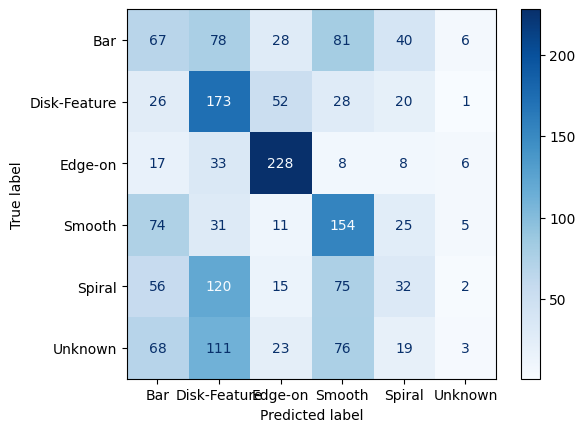

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.22      0.22       300
           1       0.32      0.58      0.41       300
           2       0.64      0.76      0.69       300
           3       0.36      0.51      0.43       300
           4       0.22      0.11      0.14       300
           5       0.13      0.01      0.02       300

    accuracy                           0.36      1800
   macro avg       0.32      0.36      0.32      1800
weighted avg       0.32      0.36      0.32      1800



In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_confusion_matrix(model, test_loader, class_to_idx, device):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Move data to the GPU (if available)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    classes = list(class_to_idx.keys())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    cr = classification_report(all_labels, all_preds)

    # Plot confusion matrix
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
    print("Classification Report:\n", cr)

# Plot confusion matrix
plot_confusion_matrix(model, test_loader, class_to_idx_test, device)


In [73]:
from collections import Counter

# Get the distribution of classes in the datasets
train_classes = [label for _, label in train_dataset]
val_classes = [label for _, label in val_dataset]
test_classes = [label for _, label in test_dataset]

# Count the occurrences of each class
train_class_count = Counter(train_classes)
val_class_count = Counter(val_classes)
test_class_count = Counter(test_classes)

print(f"Training Class Distribution: {train_class_count}")
print(f"Validation Class Distribution: {val_class_count}")
print(f"Test Class Distribution: {test_class_count}")


Training Class Distribution: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400, 4: 1400, 5: 1400})
Validation Class Distribution: Counter({0: 300, 1: 300, 2: 300, 3: 300, 4: 300, 5: 300})
Test Class Distribution: Counter({0: 300, 1: 300, 2: 300, 3: 300, 4: 300, 5: 300})


In [70]:
# Load the best model (replace 'best_model.pth' if you saved it with a different name)
model.load_state_dict(torch.load('best_model.pth', map_location=device))  # Move model to the correct device

<ipython-input-70-ddb0a4560117>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth', map_location=device))  # Move model to th

<All keys matched successfully>

In [74]:
import random
import matplotlib.pyplot as plt
from collections import defaultdict

def predict_on_random_images(model, test_loader, class_to_idx, device, num_images, rows, cols, figsize):
    model.eval()
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    # Group images by class
    class_images = defaultdict(list)

    with torch.no_grad():
        for images, labels in test_loader:
            for j in range(len(images)):
                class_name = idx_to_class[labels[j].item()]
                class_images[class_name].append((images[j], labels[j]))

    # Ensure we select images randomly from all available classes
    images_to_show = []
    true_labels = []
    predicted_labels = []

    for class_name in class_images:
        # Randomly sample images for each class (at most num_images)
        selected_samples = random.sample(class_images[class_name], min(len(class_images[class_name]), num_images // len(class_images)))

        for image, label in selected_samples:
            images_to_show.append(image)
            true_labels.append(class_name)

            # Move the data to the GPU (if available) and add batch dimension
            image = image.unsqueeze(0).to(device)

            # Get model predictions
            outputs = model(image)  # Pass the single image with batch dimension
            _, preds = torch.max(outputs, 1)

            # Collect predicted labels
            predicted_labels.append(idx_to_class[preds.item()])

            if len(images_to_show) >= num_images:
                break

    # Set up the figure for plotting
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Plot the images with true and predicted labels
    for i, ax in enumerate(axes):
        if i < len(images_to_show):
            image = images_to_show[i].permute(1, 2, 0).cpu().numpy()  # Convert to numpy for plotting
            image = (image - image.min()) / (image.max() - image.min())  # Normalize to 0-1
            ax.imshow(image)
            ax.set_title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
            ax.axis("off")
        else:
            ax.axis("off")  # Hide any extra subplots

    plt.tight_layout()
    plt.show()


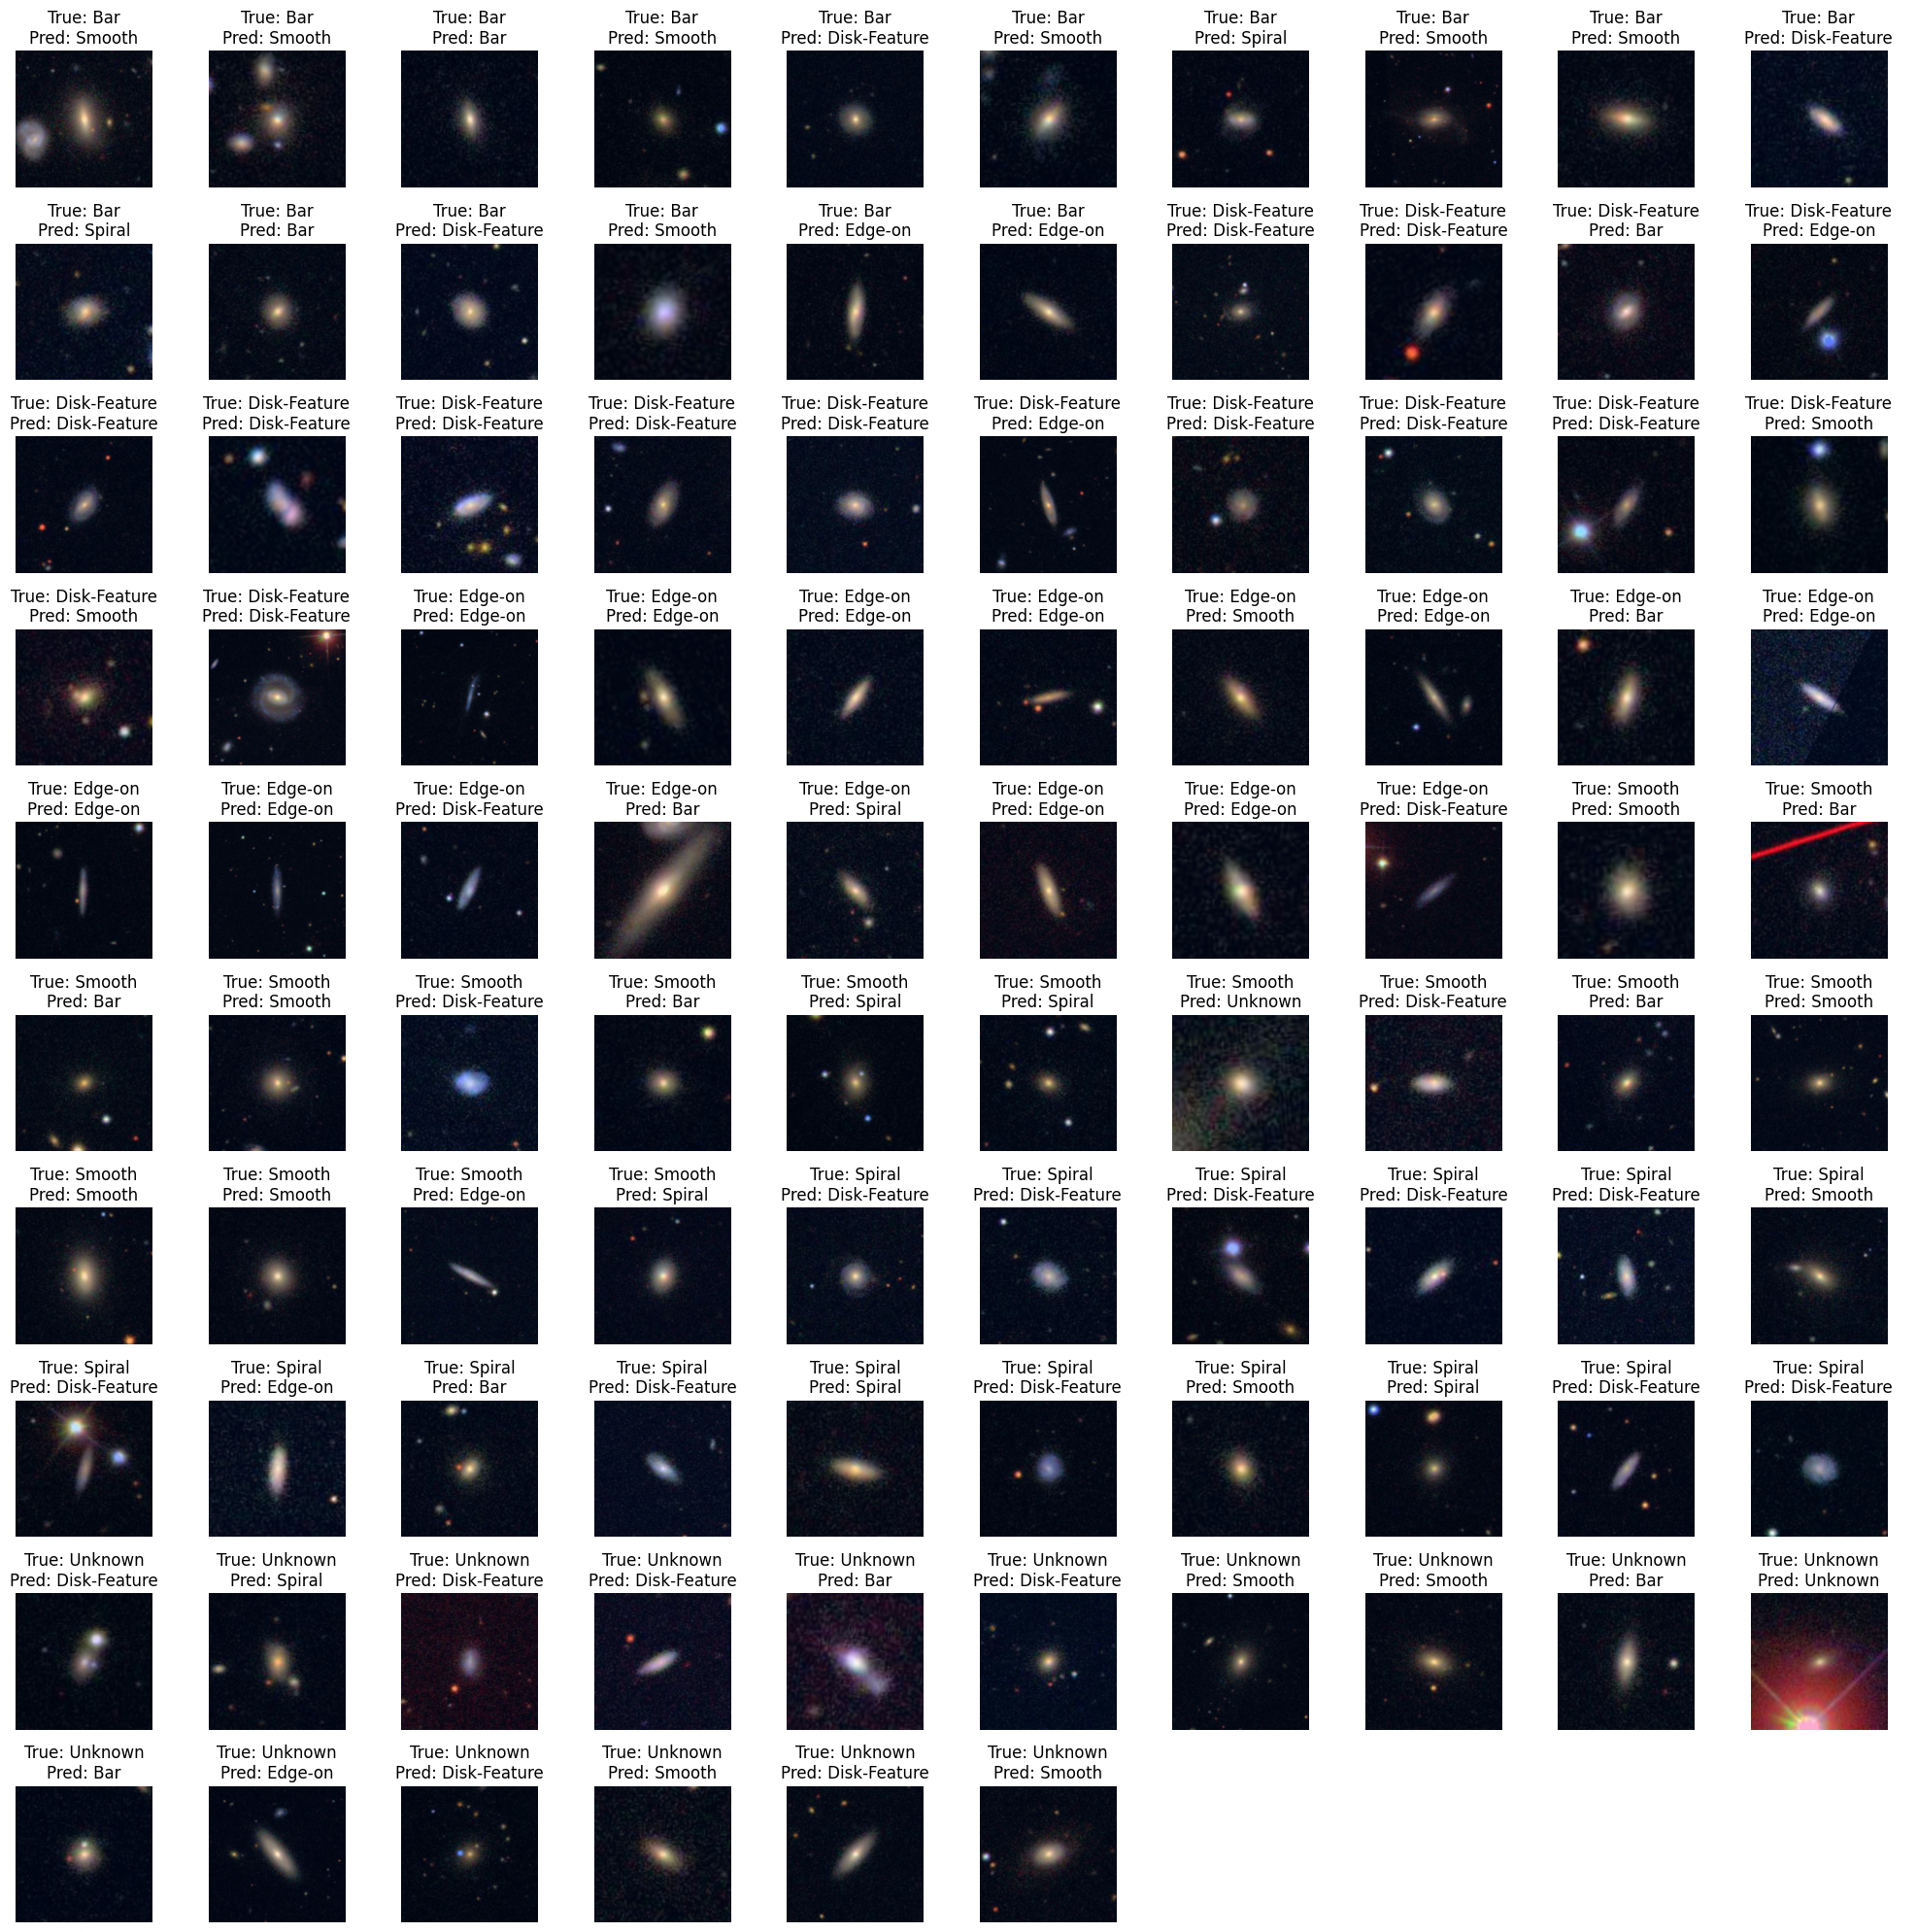

In [75]:
num_images = 100
cols=10
rows=10
figsize=(20, 20)
# Example Usage
predict_on_random_images(model, test_loader, class_to_idx_test, device, num_images, rows, cols, figsize)


In [81]:
import torch
from PIL import Image
from torchvision import transforms

model.load_state_dict(torch.load('best_model.pth', map_location=device))


<ipython-input-81-a2efda1e2548>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth', map_location=device))


<All keys matched successfully>

In [92]:

def predict_class(model, image_path, device):
    model.eval()
    # Define image transformations (same as used during training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB") # Ensure image is RGB format
    image = transform(image)

    # Add batch dimension
    image = image.unsqueeze(0).to(device)


    # Make prediction
    with torch.no_grad():
      outputs = model(image)
      _, predicted_class = torch.max(outputs, 1)

    # Get class name from predicted index
    idx_to_class = {v: k for k, v in class_to_idx_test.items()}
    predicted_class_name = idx_to_class[predicted_class.item()]

    return print(f"Predicted class: {predicted_class_name}")

![link text](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F6067505%2F8ac7df09aa0f85a1a07ac9dc0a81b57f%2FHubble_-_de_Vaucouleurs_Galaxy_Morphology_Diagram.png?generation=1611680439647479&alt=media)

Predicted class: Smooth


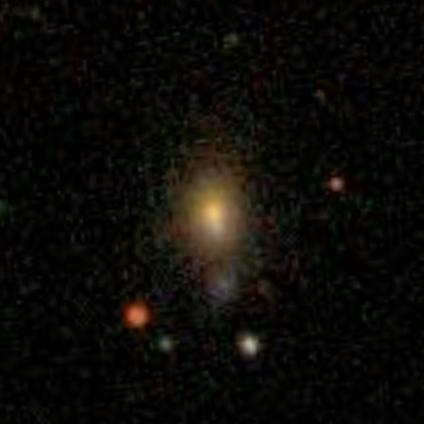

In [96]:
image_path = "/content/galaxy_data/test/Disk-Feature/174953.jpg"
predict_class(model, image_path, device)
Image.open(image_path)